In [7]:
import torch
from dinosaw.helpers import ModelTypes, model_names, get_models, get_features
from dinosaw.utils import do_2D_pca

import numpy as np
from PIL import Image

from skimage.transform import resize

import matplotlib.pyplot as plt

from interactive_seg_backend import TrainingConfig, FeatureConfig, featurise, concat_feats

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False

In [8]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'alibi_dv2_h')
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

f_cfg = FeatureConfig()
tr_cfg = TrainingConfig(feature_config=f_cfg, classifier='xgb')

In [9]:
ds_folder = 'data/trainable_seg'
image_fnames = ['NMC.png', 'steel.png']
images: list[Image.Image] = []
for image_fname in image_fnames:
    img = Image.open(f"{ds_folder}/{image_fname}").convert("RGB")
    shortest = min(img.size)
    L = 602
    sf = L / shortest
    new_size = (int(img.size[0] * sf), int(img.size[1] * sf))
    img = img.resize(new_size, resample=Image.BILINEAR)

    images.append(img)

In [ ]:
features: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}
red_features: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}

from skimage.transform import warp

for key, model in models.items():
    for img in images:
        feats = get_features(model, img, False, False,  device=DEVICE)
        reduced = do_2D_pca(feats, 9, pre_norm='std', post_norm='minmax')
        reduced_hr = resize(reduced, (img.height, img.width), order=1, mode='reflect', anti_aliasing=True)

        classical = featurise(np.array(img.convert('L')), tr_cfg)

        combined_feats = concat_feats(reduced_hr, classical)
        features[key].append(combined_feats)

        red_features[key].append(reduced_hr)

2026-02-04 15:23:33 | I | multiscale_classical_cpu.py:426 | CPU feats on (602, 1096) with `default`: weka-style features
2026-02-04 15:23:34 | I | multiscale_classical_cpu.py:426 | CPU feats on (602, 1201) with `default`: weka-style features
2026-02-04 15:23:36 | I | multiscale_classical_cpu.py:426 | CPU feats on (602, 1096) with `default`: weka-style features
2026-02-04 15:23:37 | I | multiscale_classical_cpu.py:426 | CPU feats on (602, 1201) with `default`: weka-style features


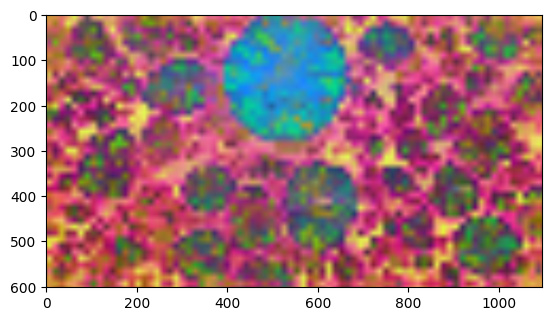

In [12]:
plt.imshow(red_features['dv2'][0][:, :, 0:3])